In [100]:
import numpy
import pandas
import matplotlib.pyplot as pyplot
import seaborn

from datetime import datetime

# ! pip install plotly.express
import plotly.express as plotly

import scipy.stats as stats

import pingouin

In [6]:
aeromexico = pandas.read_csv("AEROMEX_MX.csv", index_col=0, parse_dates=True)

aeromexico.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-01-02,22.000000,23.080000,22.000000,22.530001,22.530001,54890
2019-01-03,22.500000,23.049999,22.500000,22.770000,22.770000,88098
2019-01-04,23.430000,23.840000,22.780001,23.160000,23.160000,69569
2019-01-07,23.180000,24.500000,23.100000,23.270000,23.270000,160120
2019-01-08,23.219999,23.870001,22.820000,23.230000,23.230000,190421


In [7]:
datetime(2021, 12, 16)

datetime.datetime(2021, 12, 16, 0, 0)

Text(0.5, 1.0, 'Valor de las acciones de Aeroméxico')

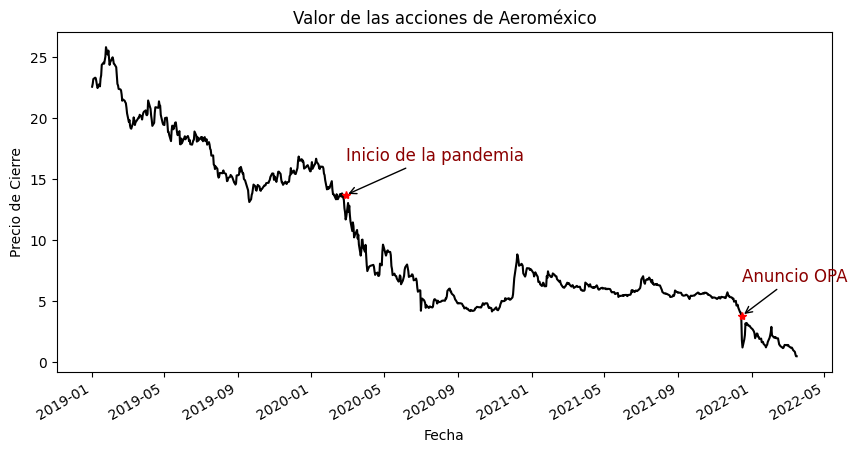

In [25]:
figure, axis = pyplot.subplots(figsize=(10, 5))

cierre = aeromexico["Close"]

cierre.plot(ax=axis, color="black", lw=1.5)

cierre.index.name = "Fecha"

crisis_data = [
    (datetime(2020, 2, 27), "Inicio de la pandemia"),
    (datetime(2021, 12, 16), "Anuncio OPA")
]

for date, label in crisis_data:
    corte = cierre.asof(date)
    if pandas.notna(corte):
        axis.annotate(label, 
                      xy=(date, corte + 2),
                      xytext=(date, corte + 6),
                      arrowprops=dict(facecolor="red", arrowstyle="->"),
                      fontsize=12,
                      color="darkred",
                      horizontalalignment="left",
                      verticalalignment="top")
        axis.plot([date], [corte + 2], marker="*", color="red")

pyplot.ylabel("Precio de Cierre")
pyplot.title("Valor de las acciones de Aeroméxico")

In [36]:
figure = plotly.line(aeromexico, 
            x=aeromexico.index, 
            y="Close",
            title="Precio de Cierre de Aeroméxico",
            labels=dict(Close="Precio de Cierre", index="Fecha"),
            template="plotly_dark") # plotly_white

figure.update_layout(
    title_font_size=24,
    title_x=0.5,
    xaxis_title="Fecha",
    yaxis_title="Precio (MNX)",
    font=dict(size=14),
    hovermode="x unified"
)

# Ford vs TESLA

In [39]:
ford = pandas.read_csv("Ford.csv", index_col=0, parse_dates=True)
tesla = pandas.read_csv("TSLA.csv", index_col=0, parse_dates=True)

In [40]:
fordClose = ford["Close"]
teslaClose = tesla["Close"]

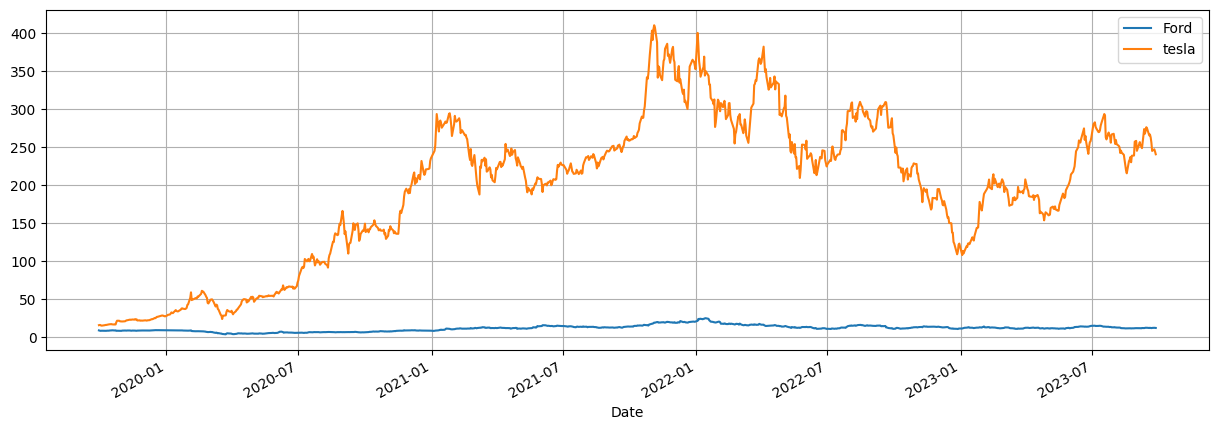

In [52]:
figure, axis = pyplot.subplots(figsize=(15, 5))

fordClose.plot(ax=axis, label="Ford")
teslaClose.plot(ax=axis, label="tesla")

pyplot.grid()
pyplot.legend()

## Rendimientos

$$
r_t = \ln{\left( \frac{x_t}{x_{t-1}} \right)} = \ln{\left( x_t \right)} - \ln{\left( x_{t-1} \right)}
$$

In [53]:
ford["ren"] = numpy.log(ford["Close"].pct_change() + 1).dropna()
tesla["ren"] = numpy.log(tesla["Close"].pct_change() + 1).dropna()

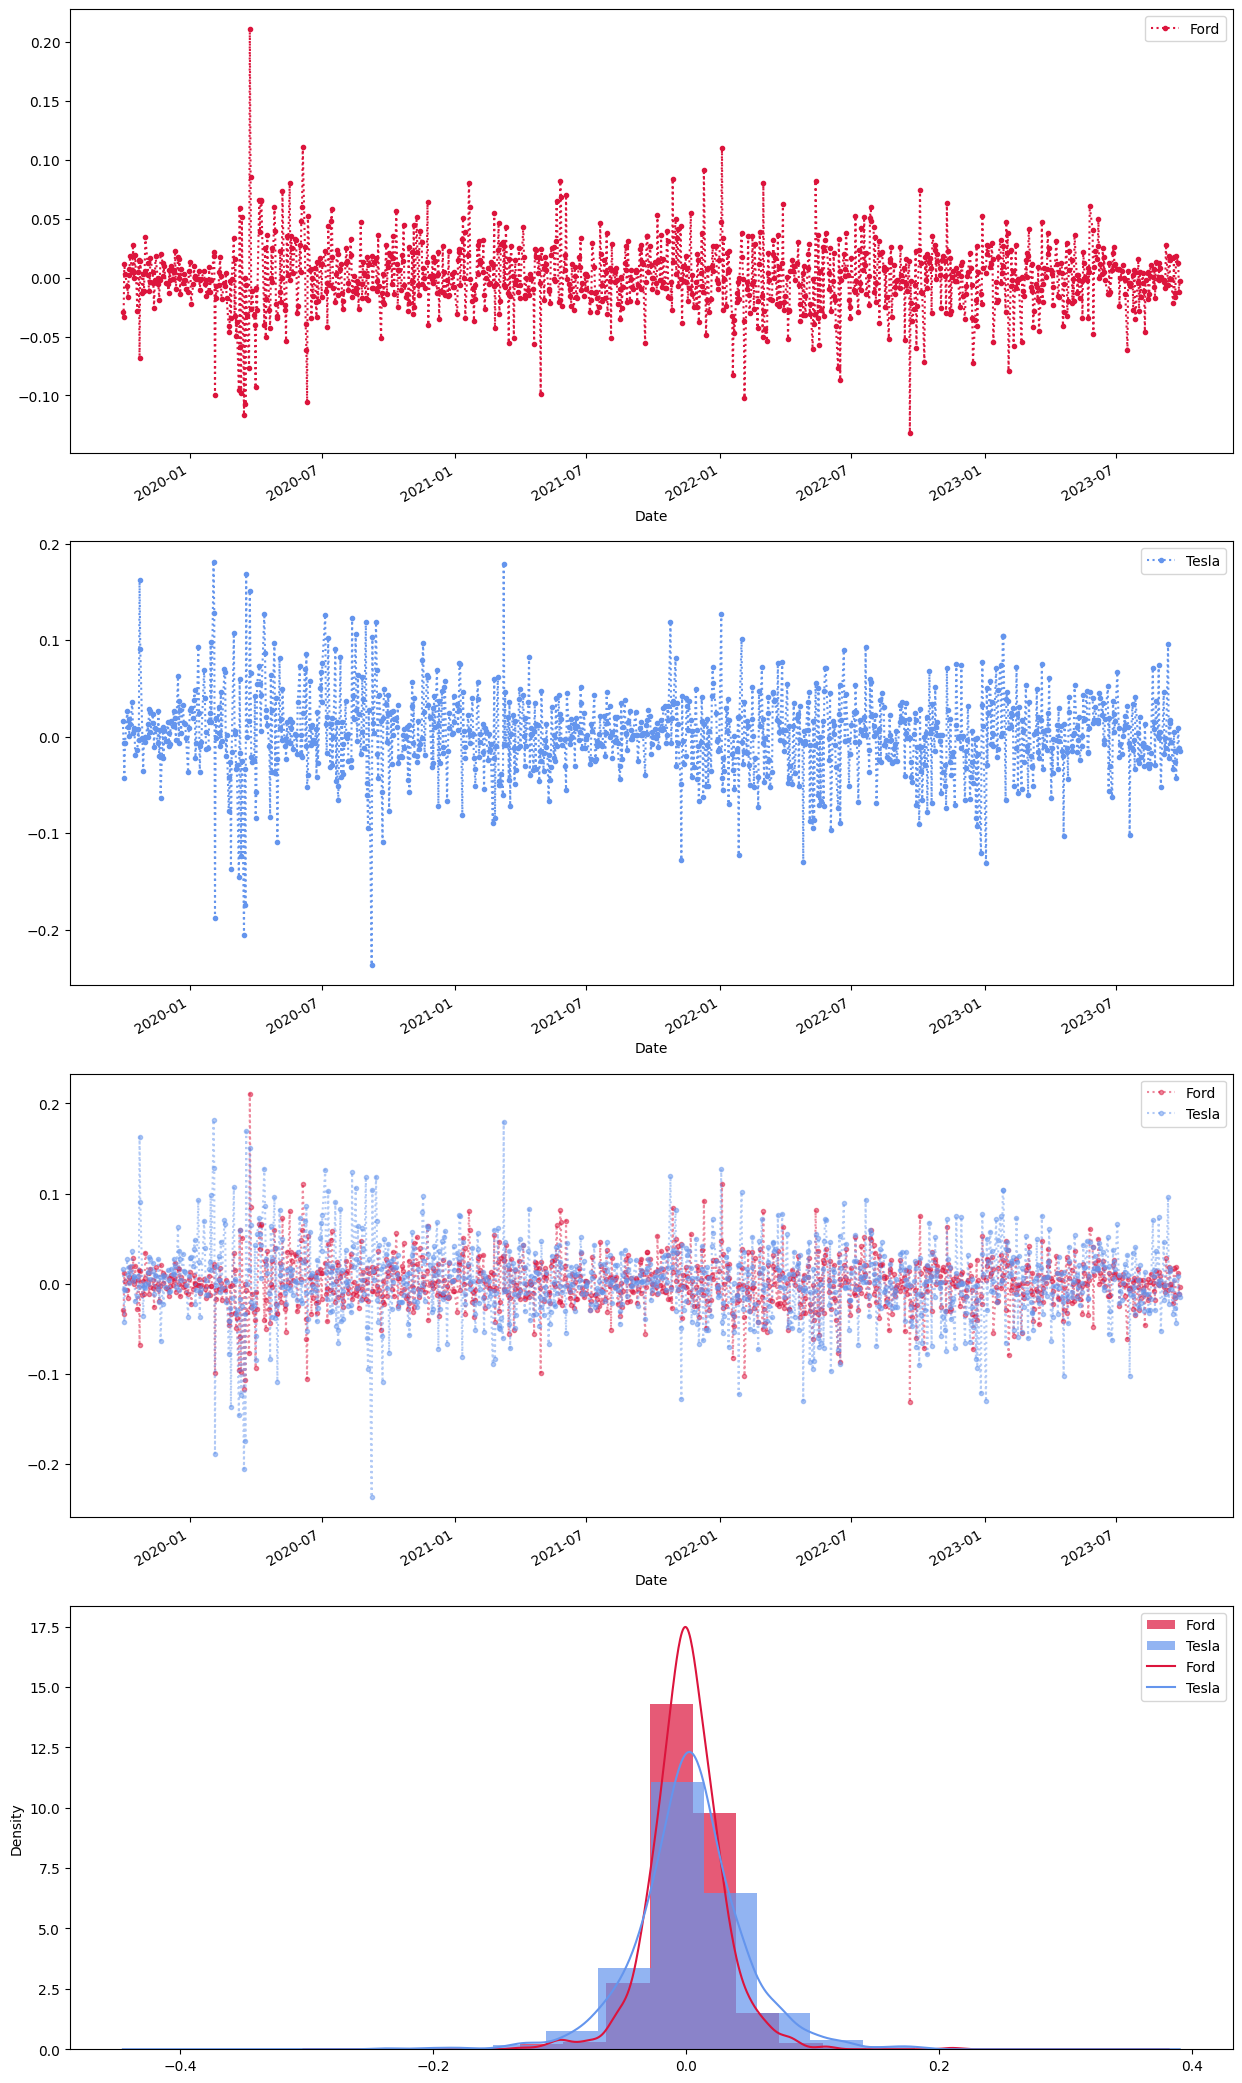

In [103]:
figure, axis = pyplot.subplots(nrows=4, figsize=(15, 30))

ford["ren"].plot(ax=axis[0], color="crimson", marker=".", linestyle=":", label="Ford")
tesla["ren"].plot(ax=axis[1], color="cornflowerblue", marker=".", linestyle=":", label="Tesla")
ford["ren"].plot(ax=axis[2], color="crimson", marker=".", linestyle=":", label="Ford", alpha=0.5)
tesla["ren"].plot(ax=axis[2], color="cornflowerblue", marker=".", linestyle=":", label="Tesla", alpha=0.5)
ford["ren"].plot.hist(ax=axis[3], color="crimson", label="Ford", density=True, alpha=0.7)
tesla["ren"].plot.hist(ax=axis[3], color="cornflowerblue", label="Tesla", density=True, alpha=0.7)
ford["ren"].plot.density(ax=axis[3], color="crimson", label="Ford")
tesla["ren"].plot.density(ax=axis[3], color="cornflowerblue", label="Tesla")
axis[0].legend()
axis[1].legend()
axis[2].legend()
axis[3].legend()

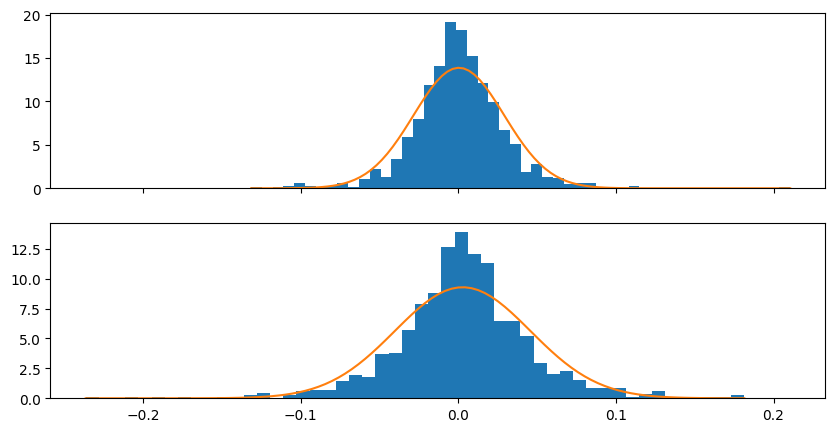

In [99]:
x_ret_ford = numpy.linspace(ford["ren"].min(), ford["ren"].max(), 100)
x_ret_tesla = numpy.linspace(tesla["ren"].min(), tesla["ren"].max(), 100)

pdf_ret_ford = stats.norm.pdf(x_ret_ford, ford["ren"].mean(), ford["ren"].std())
pdf_ret_tesla = stats.norm.pdf(x_ret_tesla, tesla["ren"].mean(), tesla["ren"].std())

figure, axis = pyplot.subplots(nrows=2, figsize=(10, 5), sharex=True)

axis[0].hist(ford["ren"], bins=50, density=True)
axis[0].plot(x_ret_ford, pdf_ret_ford)

axis[1].hist(tesla["ren"], bins=50, density=True)
axis[1].plot(x_ret_tesla, pdf_ret_tesla)

## Q-Q Plot (Prueba de normalidad)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

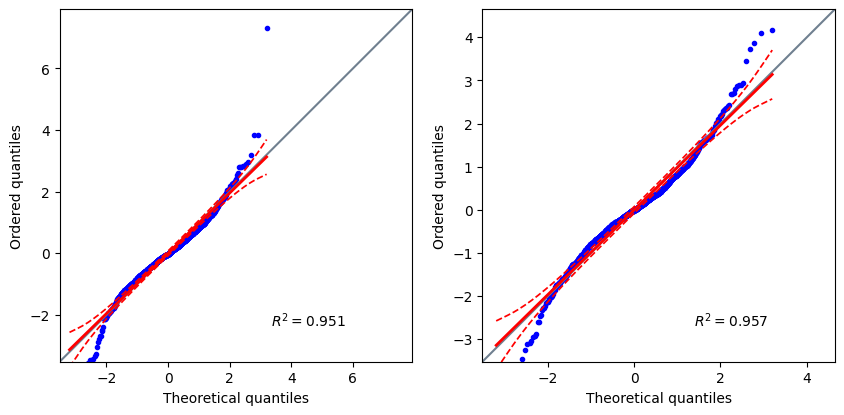

In [117]:
figure, axis = pyplot.subplots(nrows=1, ncols=2, figsize=(10, 5))

pingouin.qqplot(ford["ren"], dist="norm", confidence=0.95, ax=axis[0], marker=".")
pingouin.qqplot(tesla["ren"], dist="norm", confidence=0.95, ax=axis[1], marker=".")